<a href="https://colab.research.google.com/github/Pranay-256/Sales-Analysis-Python-PowerBI-Project/blob/main/sales_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***1.Importing Libraries and adding some extra features***

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
%config InlineBackend.figure_format = 'retina'

def format_axis_millions(ax, axis='x'):
    """Formats the x or y axis to show values in millions (e.g. 25.0M)."""
    formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
    if axis == 'x':
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)

***2.Data Exploration***

---



In [ ]:
df = pd.read_excel("Sales data.xlsx")

print(df.shape)
df.head()

(700, 16)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,"1,513.00",3,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,"1,006.00",10,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,"1,725.00",10,350,"603,750.00",0.00,"603,750.00","448,500.00","155,250.00",2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,"1,513.00",10,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,"1,006.00",120,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",2014-06-01,6,June,2014


In [ ]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print()
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

***3.Data Cleaning***

---



**a. Stripping Column Headers**

In [ ]:
df.columns = df.columns.str.strip()

**b. Filling Null values**

In [ ]:
df['Discount Band'] = df['Discount Band'].fillna('None')

**c. Changing Data Types of Date and Units Sold Column**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.style.format({'Date': '%Y-%m-%d'})
df['Units Sold'] = df['Units Sold'].astype(int)

**d. Exploring the unique values from the following columns**

In [ ]:
print("\nUnique Segments:", df['Segment'].unique())
print("Unique Countries:", df['Country'].unique())
print("Unique Products:", df['Product'].unique())
print("Date range:", df['Date'].min(), "to", df['Date'].max())


Unique Segments: ['Government' 'Midmarket' 'Channel Partners' 'Enterprise' 'Small Business']
Unique Countries: ['Germany' 'Canada' 'France' 'Mexico' 'United States of America']
Unique Products: ['Carretera' 'Paseo' 'Velo' 'VTT' 'Amarilla' 'Montana']
Date range: 2013-09-01 00:00:00 to 2014-12-01 00:00:00


**e. Fixing the values of Manufacturing Price column because it has misleading values**

In [ ]:
df['Manufacturing Price'] = (df['COGS'] / df['Units Sold']).round(2)

In [ ]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,None,1513,260.00,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",2014-12-01,12,December,2014
1,Government,Germany,Paseo,None,1006,260.00,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",2014-06-01,6,June,2014
2,Government,Canada,Paseo,None,1725,260.00,350,"603,750.00",0.00,"603,750.00","448,500.00","155,250.00",2013-11-01,11,November,2013
3,Government,Germany,Paseo,None,1513,260.00,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",2014-12-01,12,December,2014
4,Government,Germany,Velo,None,1006,260.00,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",2014-06-01,6,June,2014


In [ ]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


**f. Statistical values of Numerical columns**

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Units Sold,700.00,"1,608.27",200.00,905.00,"1,542.50","2,228.75","4,492.00",867.41
Manufacturing Price,700.00,94.00,3.00,5.00,10.00,250.00,260.23,108.89
Sale Price,700.00,118.43,7.00,12.00,20.00,300.00,350.00,136.78
Gross Sales,700.00,"182,759.43","1,799.00","17,391.75","37,980.00","279,025.00","1,207,500.00","254,262.28"
Discounts,700.00,"13,150.35",0.00,800.32,"2,585.25","15,956.34","149,677.50","22,962.93"
Sales,700.00,"169,609.07","1,655.08","15,928.00","35,540.20","261,077.50","1,159,200.00","236,726.35"
COGS,700.00,"145,475.21",918.00,"7,490.00","22,506.25","245,607.50","950,625.00","203,865.51"
Profit,700.00,"24,133.86","-40,617.50","2,805.96","9,242.20","22,662.00","262,200.00","42,760.63"
Date,700,2014-04-28 21:36:00,2013-09-01 00:00:00,2013-12-24 06:00:00,2014-05-16 12:00:00,2014-09-08 12:00:00,2014-12-01 00:00:00,NaN
Month Number,700.00,7.90,1.00,5.75,9.00,10.25,12.00,3.38


***4.Feature Engineering & Exploratory Data Analysis***

---



**a. Adding Profit Margin and YearMonth Column**

In [ ]:
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100
df['YearMonth'] = df['Year'].astype(str) + '-' + df['Month Name'].str[:3]
df.head(2)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,Profit Margin %,YearMonth
0,Government,Germany,Carretera,None,1513,260.00,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",2014-12-01,12,December,2014,25.71,2014-Dec
1,Government,Germany,Paseo,None,1006,260.00,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",2014-06-01,6,June,2014,25.71,2014-Jun


**b. Primary KPIs**

In [ ]:
total_orders = len(df)
total_sales = df['Sales'].sum()
total_units_sold = df['Units Sold'].sum()
total_profit = df['Profit'].sum()

print(f"total orders: {total_orders}\n")
print()
print(f"total units sold: {total_units_sold}\n")
print()
print(f"total sales: {total_sales.round(2)}\n")
print()
print(f"total profit: {total_profit.round(2)}\n")

total orders: 700


total units sold: 1125788


total sales: 118726350.26


total profit: 16893702.26



**c. Total Sales and Profit by Countries**

In [ ]:
country_sales_profit = (df.groupby('Country')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index())
country_sales_profit.index += 1
print("Sales and Profit by Country:\n")
country_sales_profit

Sales and Profit by Country:



,Country,Sales,Profit
1,United States of America,"25,029,830.16","2,995,540.67"
2,Canada,"24,887,654.89","3,529,228.89"
3,France,"24,354,172.28","3,781,020.78"
4,Germany,"23,505,340.82","3,680,388.82"
5,Mexico,"20,949,352.11","2,907,523.11"


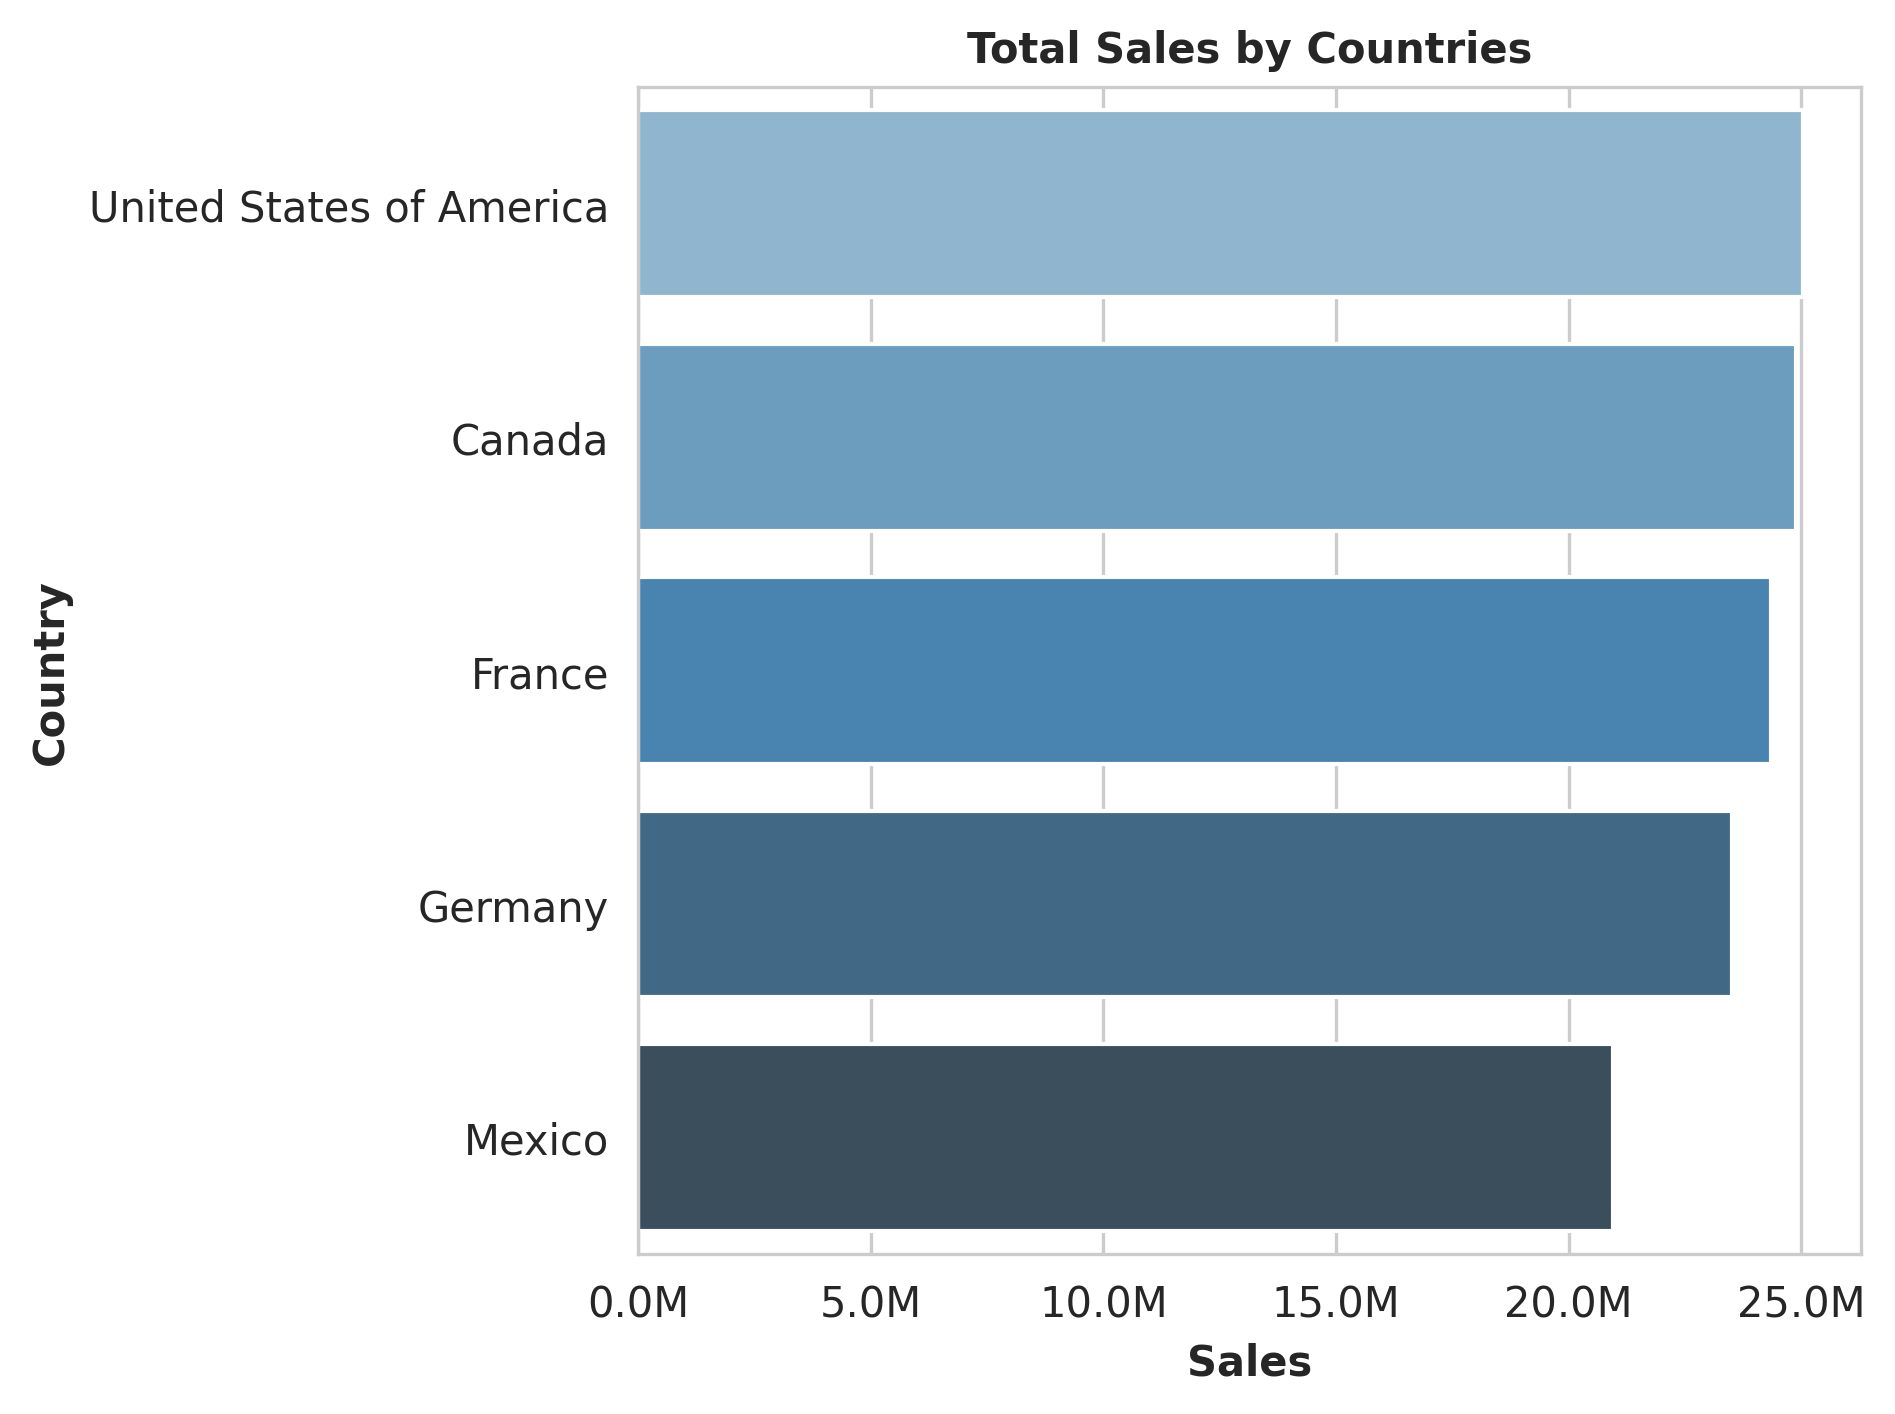

In [ ]:
colors = sns.color_palette("Blues_d", len(country_sales_profit))
plt.figure(dpi = 150)
ax = sns.barplot(x = country_sales_profit['Sales'], y  = country_sales_profit['Country'], palette = colors)
format_axis_millions(ax, axis='x')
plt.xlabel("Sales", fontsize = 10, fontweight = 'bold')
plt.ylabel("Country", fontsize = 10, fontweight = 'bold')
plt.title("Total Sales by Countries", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

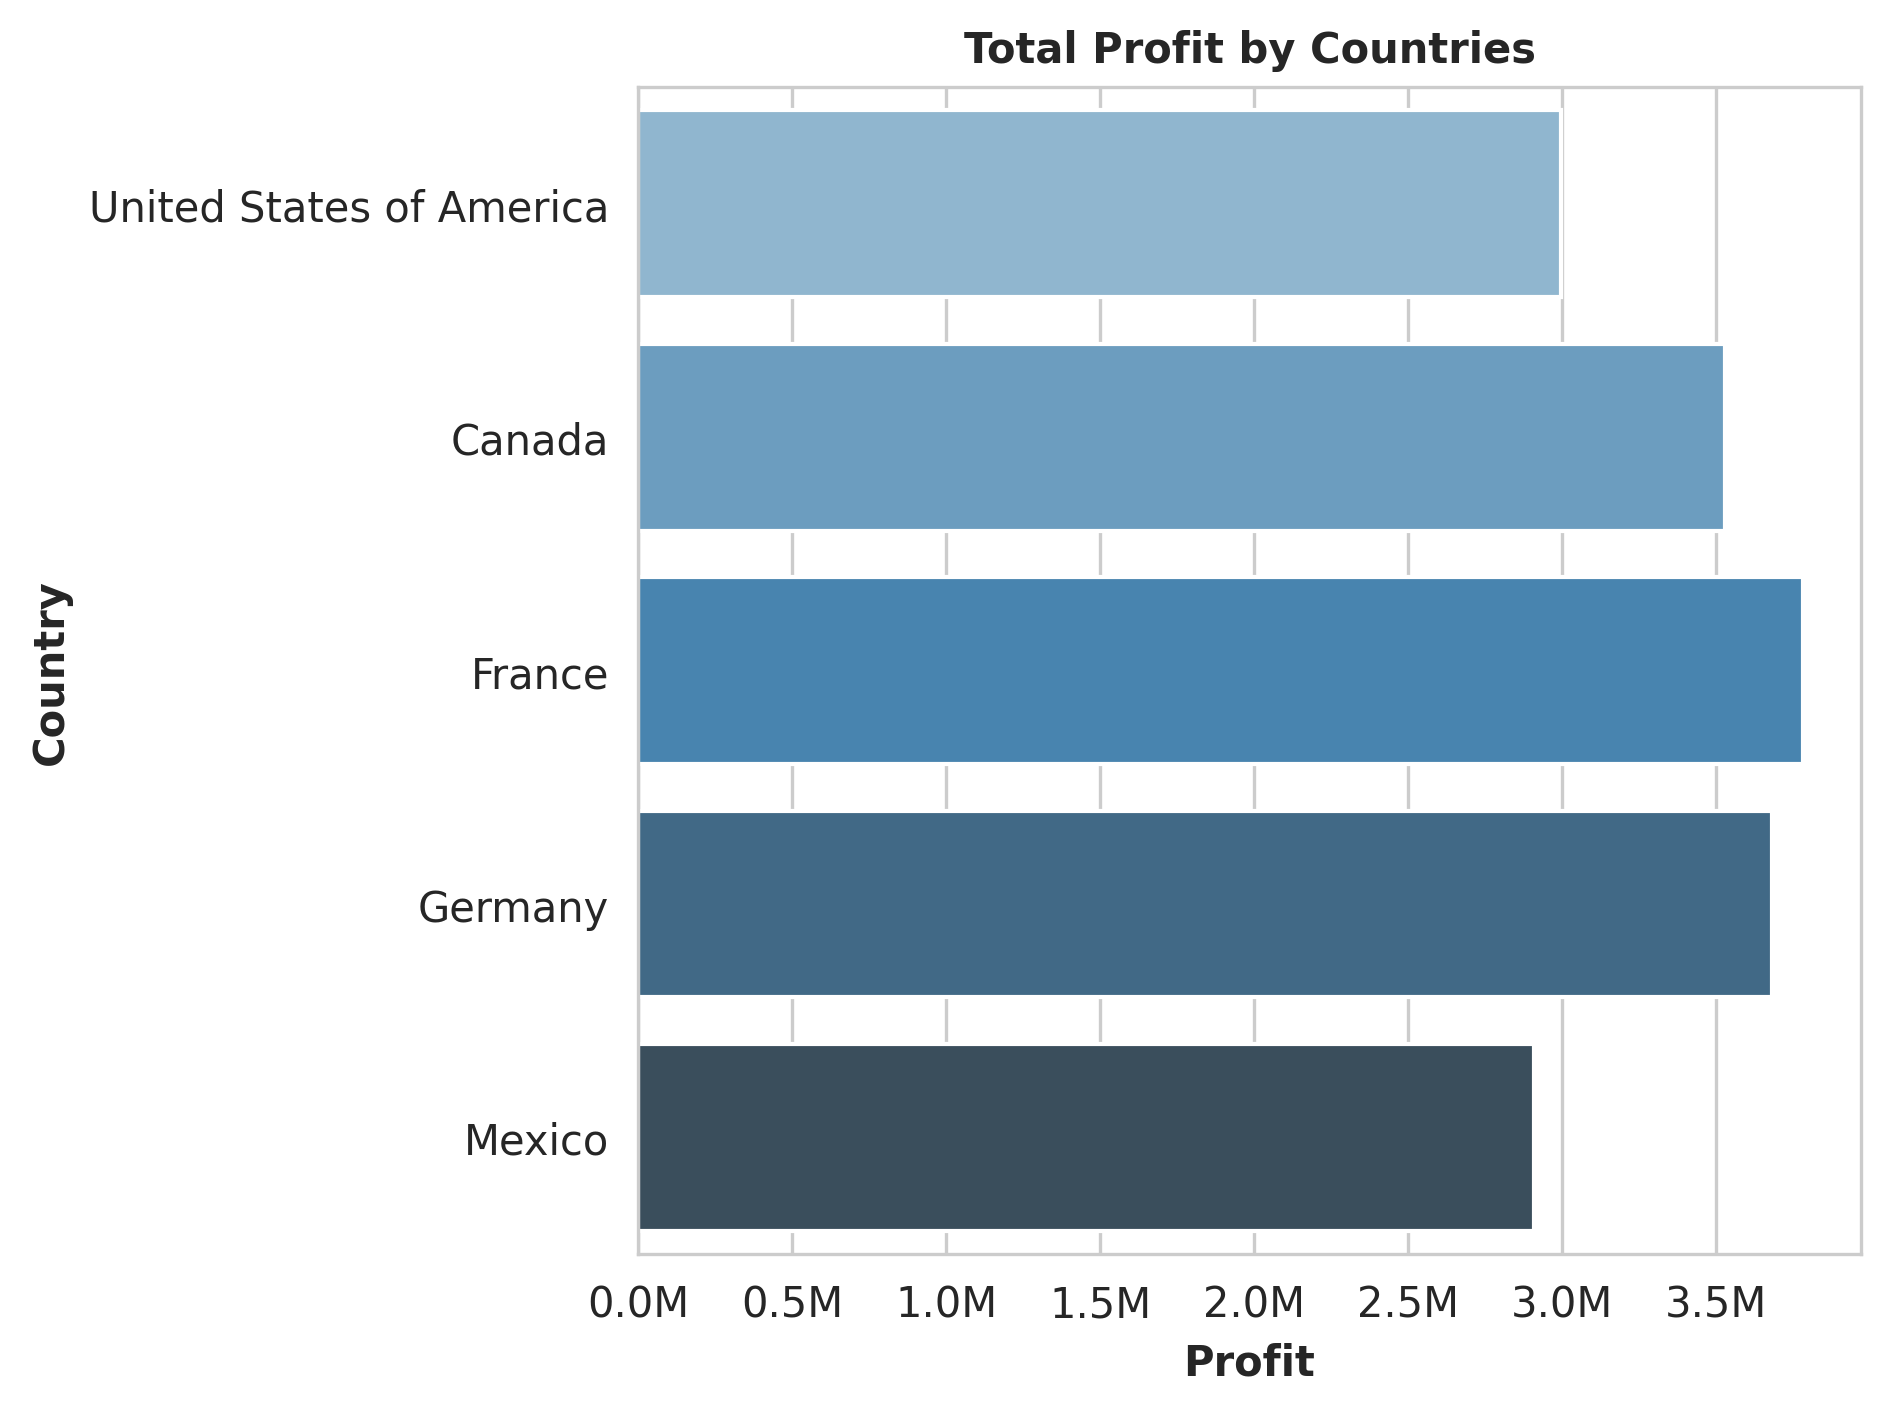

In [ ]:
colors = sns.color_palette("Blues_d", len(country_sales_profit))
plt.figure(dpi = 150)
ax = sns.barplot(x = country_sales_profit['Profit'], y  = country_sales_profit['Country'], palette = colors)
format_axis_millions(ax, axis='x')
plt.xlabel("Profit", fontsize = 10, fontweight = 'bold')
plt.ylabel("Country", fontsize = 10, fontweight = 'bold')
plt.title("Total Profit by Countries", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

**d. Total Sales and Profit by Segments**

In [ ]:
segment_sales_profit = df.groupby('Segment')[['Sales','Profit']].sum().sort_values(by = 'Sales', ascending=False).reset_index()
segment_sales_profit.index += 1
print("Sales and Profit by Segment:\n")
segment_sales_profit

Sales and Profit by Segment:



,Segment,Sales,Profit
1,Government,"52,504,260.67","11,388,173.17"
2,Small Business,"42,427,918.50","4,143,168.50"
3,Enterprise,"19,611,694.38","-614,545.62"
4,Midmarket,"2,381,883.08","660,103.07"
5,Channel Partners,"1,800,593.64","1,316,803.14"


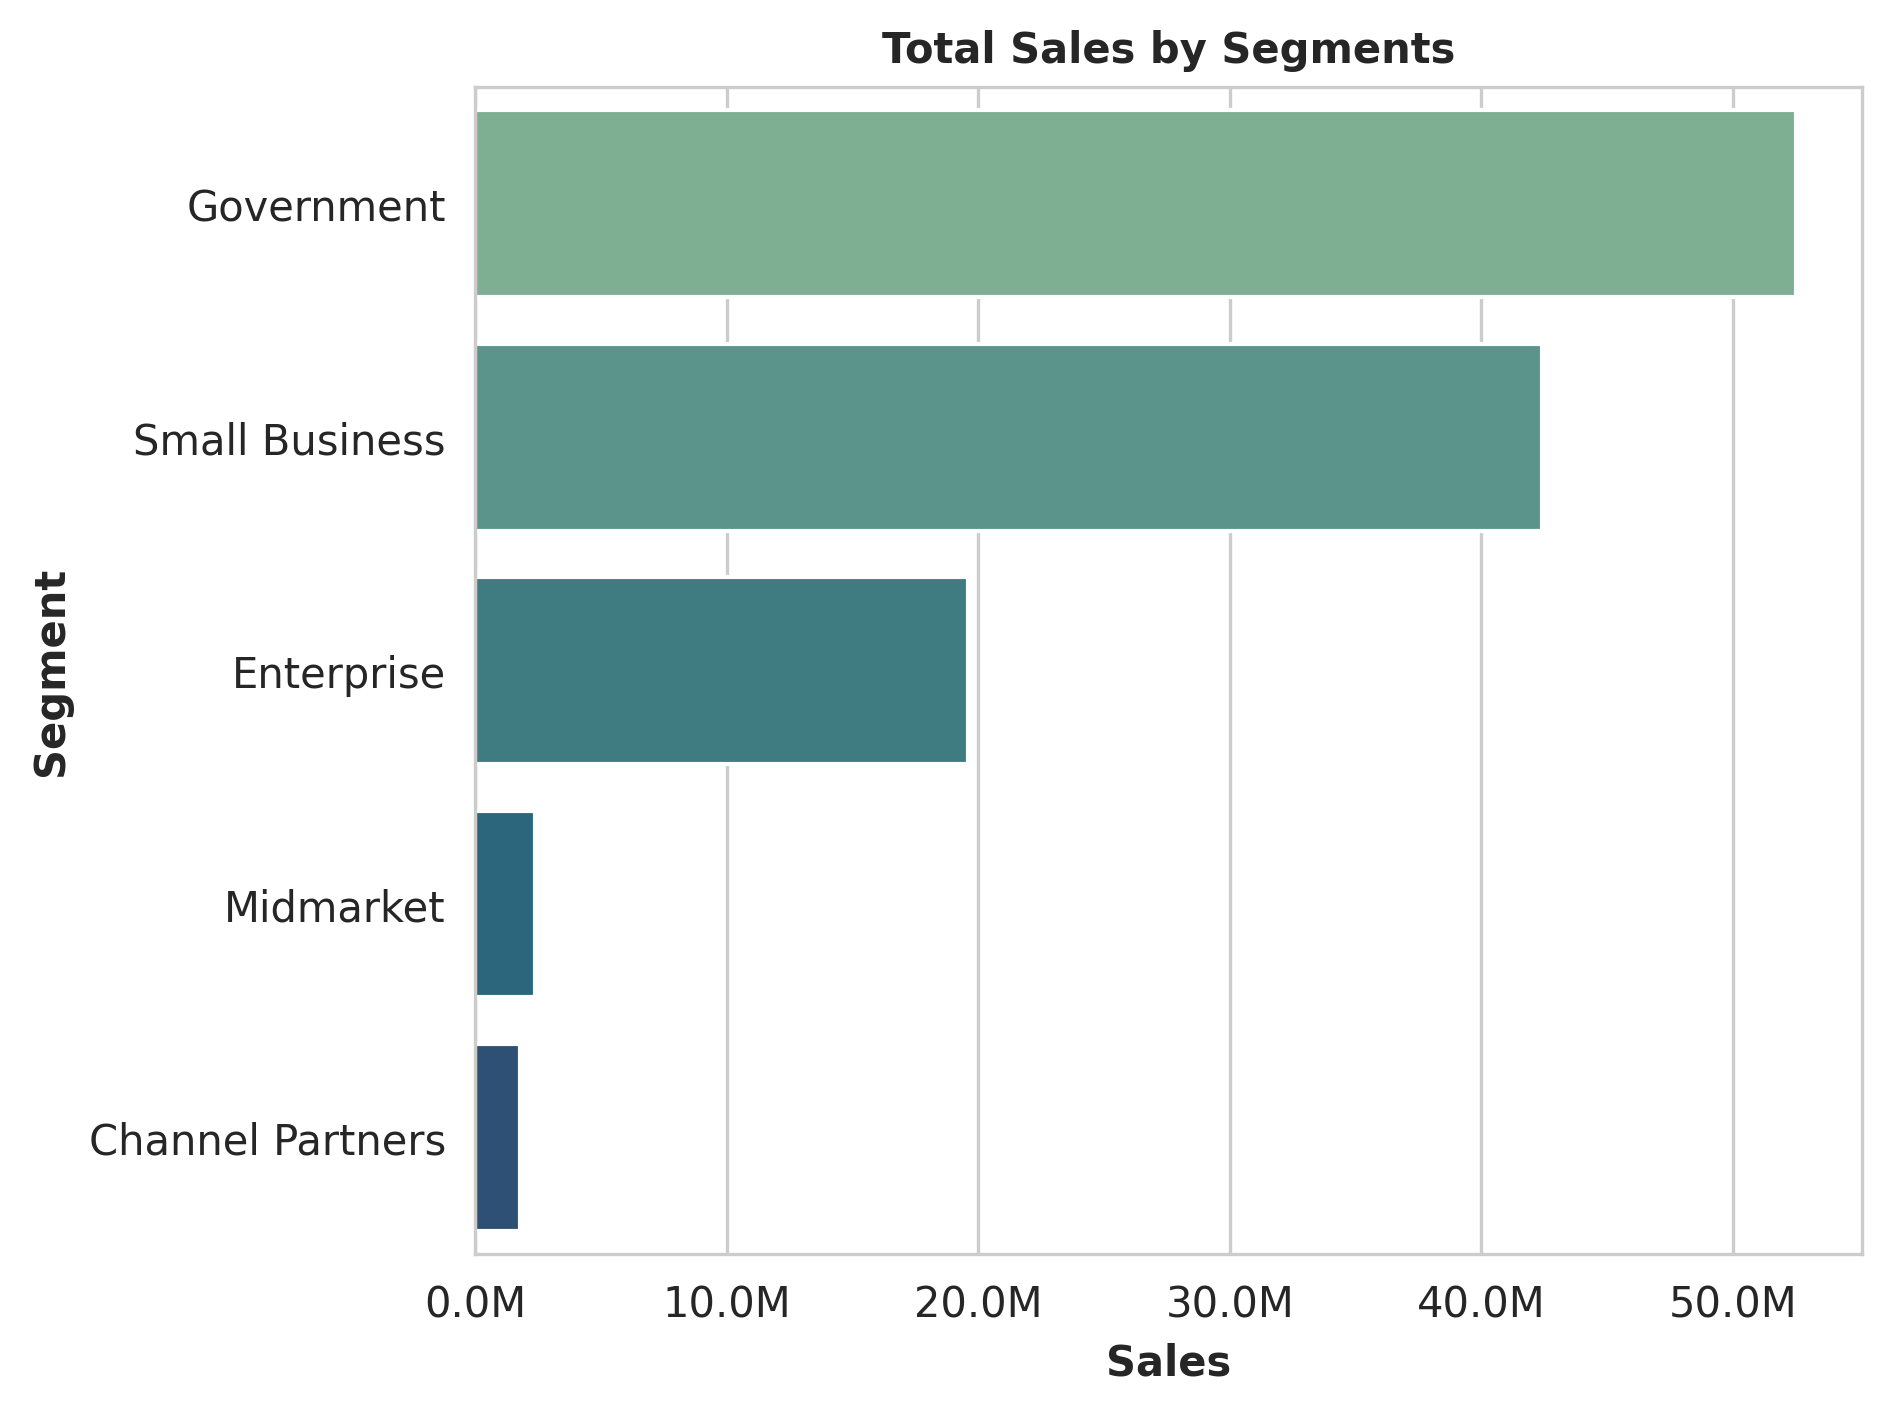

In [ ]:
colors = sns.color_palette("crest", len(segment_sales_profit))
plt.figure(dpi = 150)
ax = sns.barplot(x = segment_sales_profit['Sales'], y  = segment_sales_profit['Segment'], palette = colors)
format_axis_millions(ax, axis='x')
plt.xlabel("Sales", fontsize = 10, fontweight = 'bold')
plt.ylabel("Segment", fontsize = 10, fontweight = 'bold')
plt.title("Total Sales by Segments", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

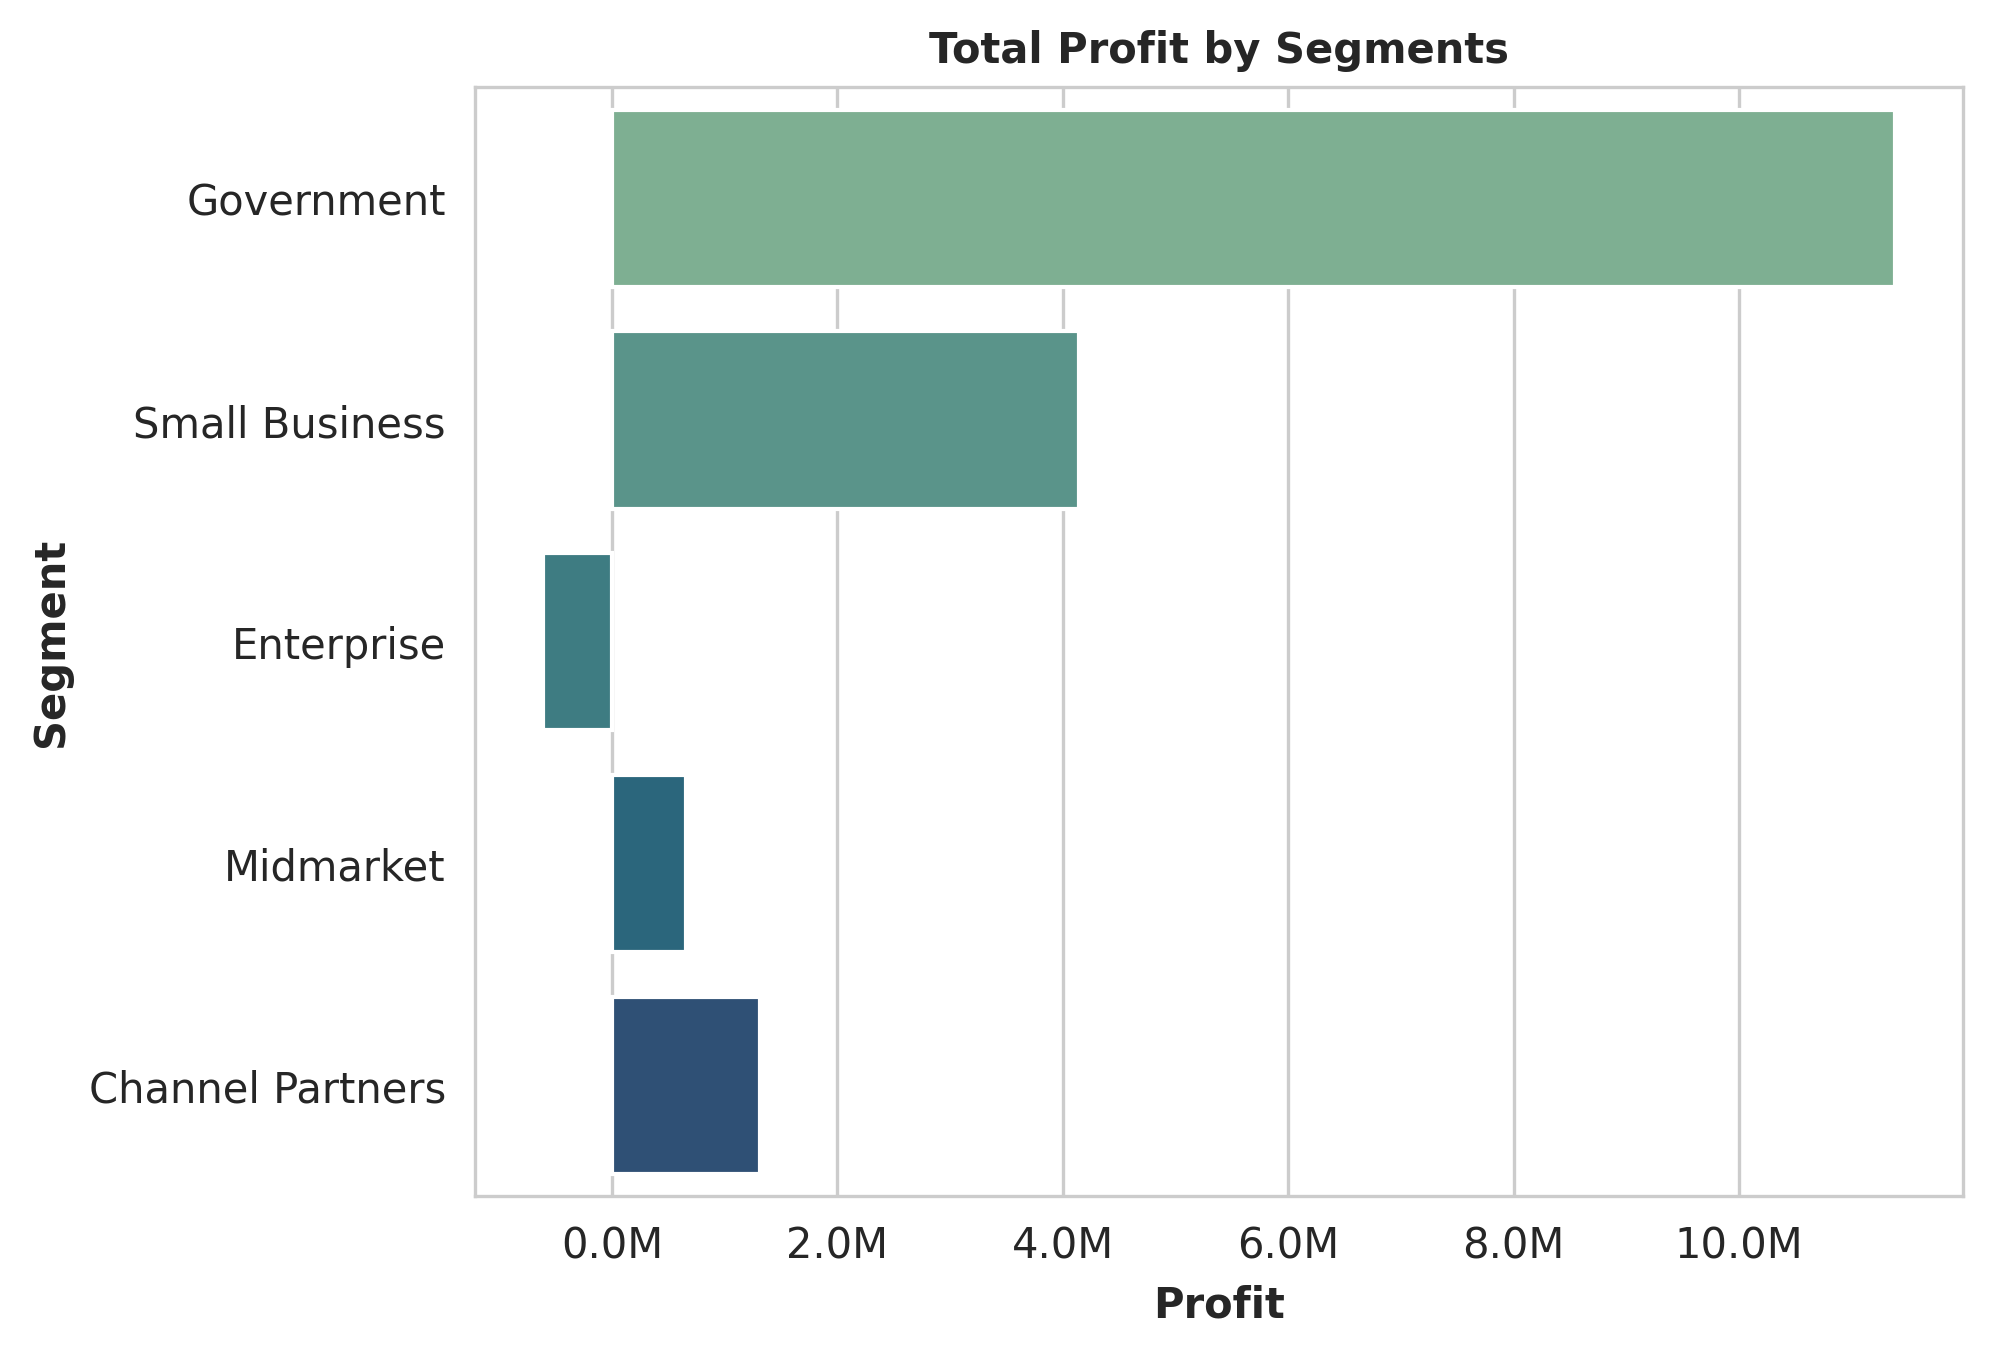

In [ ]:
colors = sns.color_palette("crest", len(segment_sales_profit))
plt.figure(dpi = 150)
ax = sns.barplot(x = segment_sales_profit['Profit'], y  = segment_sales_profit['Segment'], palette = colors)
format_axis_millions(ax, axis='x')
plt.xlabel("Profit", fontsize = 10, fontweight = 'bold')
plt.ylabel("Segment", fontsize = 10, fontweight = 'bold')
plt.title("Total Profit by Segments", fontsize=10, fontweight="bold")
plt.show()

**e. Sales and Profit Monthly Trend**

In [ ]:
monthly_sales_profit = df.groupby(['Year', 'Month Number', 'YearMonth'])[['Sales', 'Profit']].sum().sort_values(by = ['Year', 'Month Number']).reset_index()
monthly_sales_profit.index += 1
print("Monthly Sales and Profit Trend:\n")
monthly_sales_profit

Monthly Sales and Profit Trend:



,Year,Month Number,YearMonth,Sales,Profit
1,2013,9,2013-Sep,"4,484,000.03","763,603.03"
2,2013,10,2013-Oct,"9,295,611.10","1,657,795.10"
3,2013,11,2013-Nov,"7,267,203.30","765,502.30"
4,2013,12,2013-Dec,"5,368,441.08","691,564.08"
5,2014,1,2014-Jan,"6,607,761.68","814,028.68"
6,2014,2,2014-Feb,"7,297,531.39","1,148,547.39"
7,2014,3,2014-Mar,"5,586,859.87","669,866.87"
8,2014,4,2014-Apr,"6,964,775.07","929,984.57"
9,2014,5,2014-May,"6,210,211.06","828,640.06"
10,2014,6,2014-Jun,"9,518,893.82","1,473,753.82"


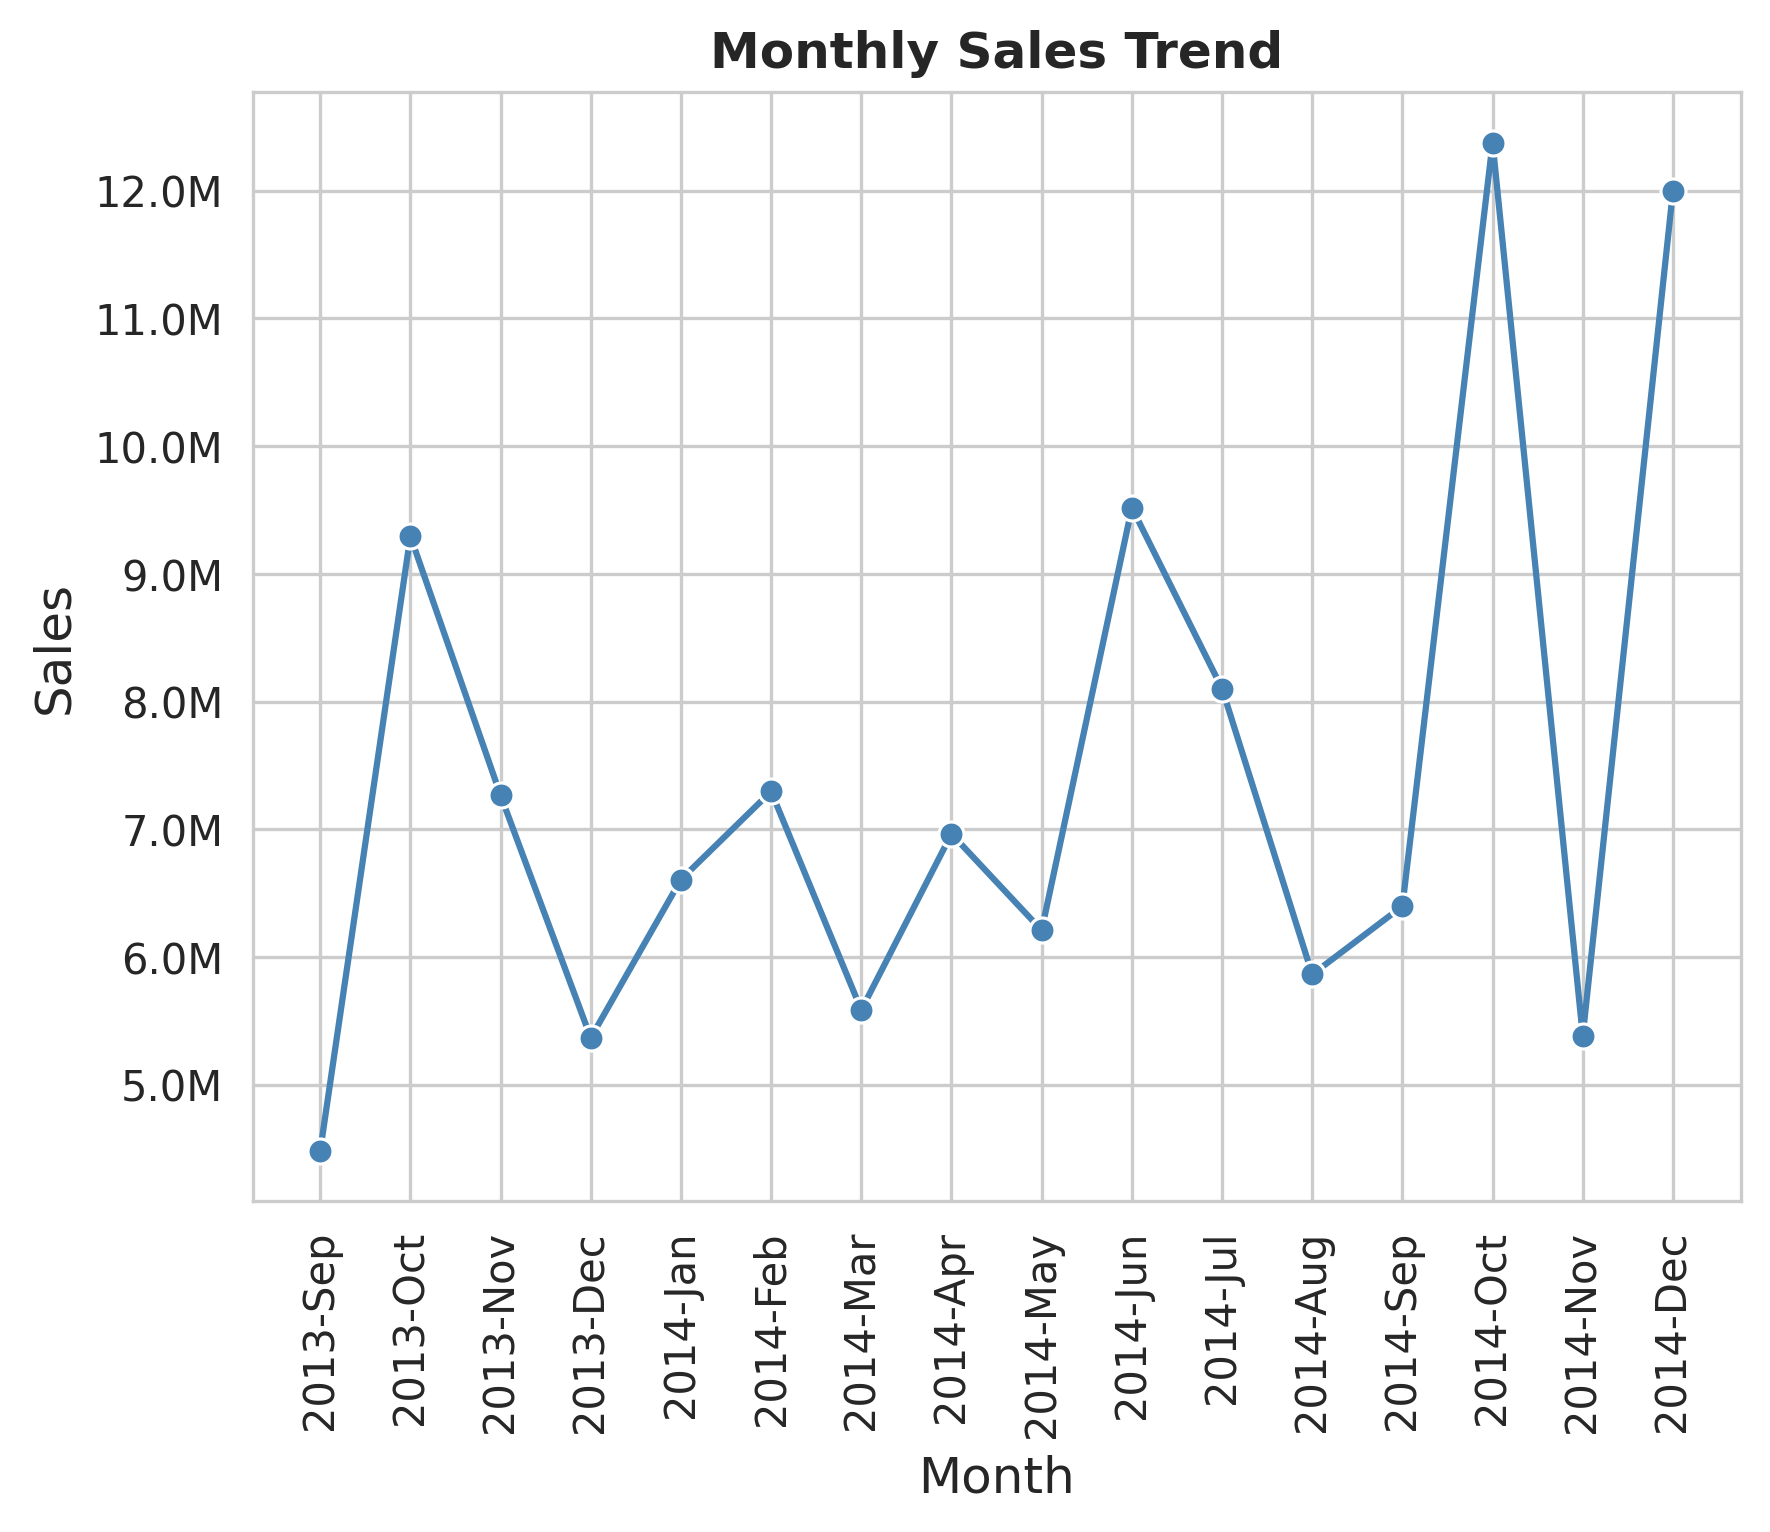

In [ ]:
plt.figure(dpi=150)
ax = sns.lineplot(x = monthly_sales_profit['YearMonth'], y = monthly_sales_profit['Sales'], marker='o',color='steelblue')
format_axis_millions(ax, axis='y')
plt.xlabel("Month", fontsize= 12)
plt.ylabel("Sales", fontsize= 12)
plt.title("Monthly Sales Trend", fontsize=12, fontweight='bold')
plt.xticks(rotation= 90)
plt.show()

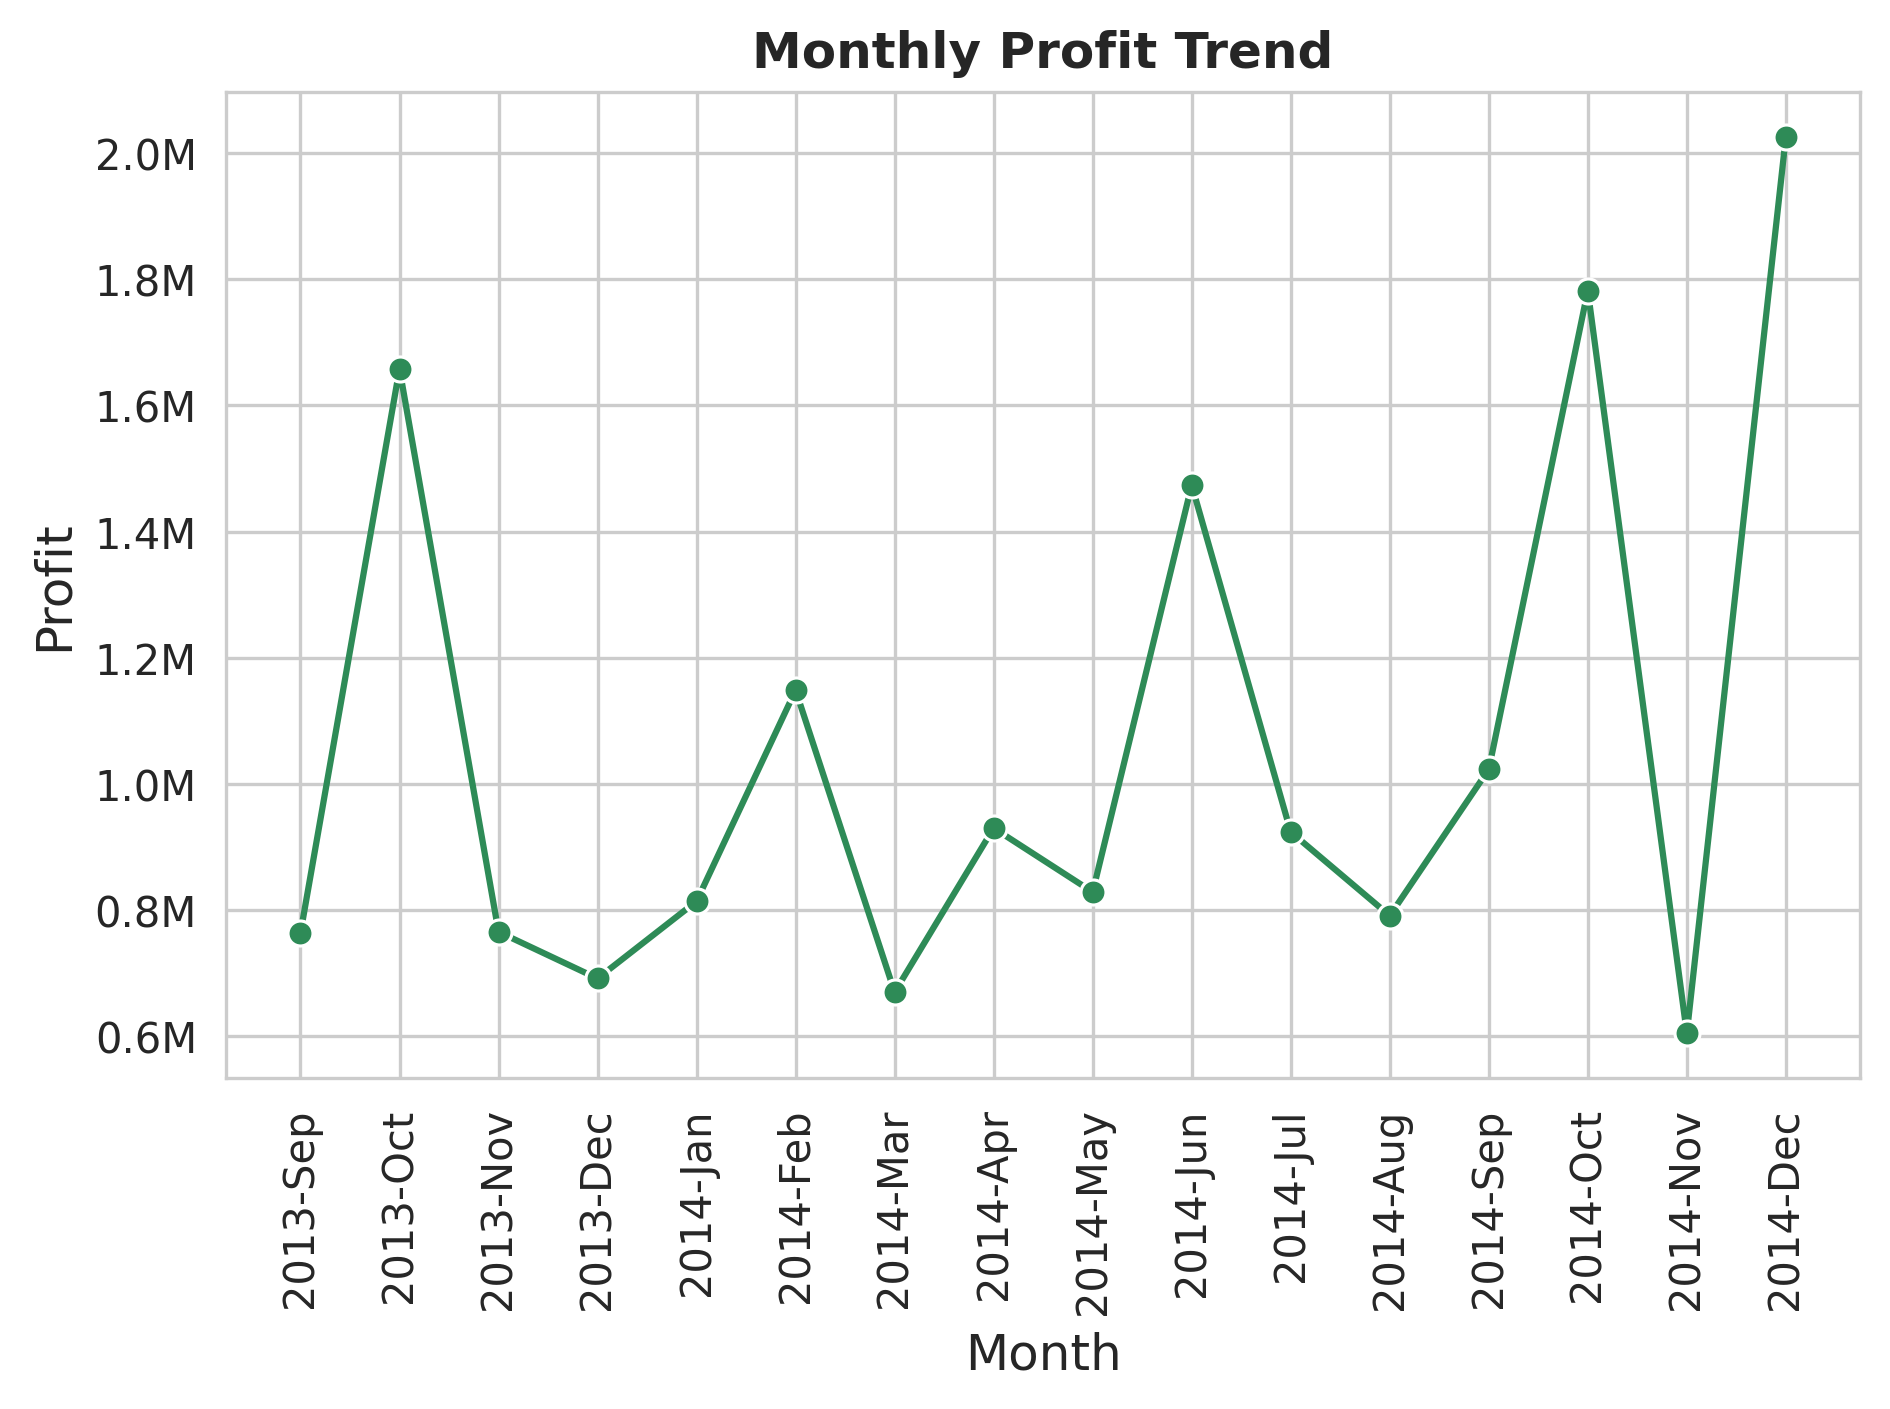

In [ ]:
plt.figure(dpi= 150)
ax = sns.lineplot(x= monthly_sales_profit['YearMonth'], y= monthly_sales_profit['Profit'], marker='o', color='seagreen')
format_axis_millions(ax, axis='y')
plt.title("Monthly Profit Trend", fontsize=12, fontweight='bold')
plt.xlabel("Month", fontsize= 12)
plt.ylabel("Profit", fontsize= 12)
plt.xticks(rotation= 90)
plt.tight_layout()
plt.show()

**f. Units Sold, Sales and Profit by Products**

In [ ]:
top_products = df.groupby('Product')[['Units Sold', 'Sales', 'Profit']].sum().sort_values(by = 'Sales', ascending=False).reset_index()
top_products.index += 1
print("Units Sold, Sales and Profit by Products:\n")
top_products

Units Sold, Sales and Profit by Products:



,Product,Units Sold,Sales,Profit
1,Paseo,338236,"33,011,143.95","4,797,437.95"
2,VTT,168779,"20,511,921.02","3,034,608.02"
3,Velo,162423,"18,250,059.46","2,305,992.46"
4,Amarilla,155312,"17,747,116.06","2,814,104.06"
5,Montana,154195,"15,390,801.88","2,114,754.88"
6,Carretera,146843,"13,815,307.88","1,826,804.89"


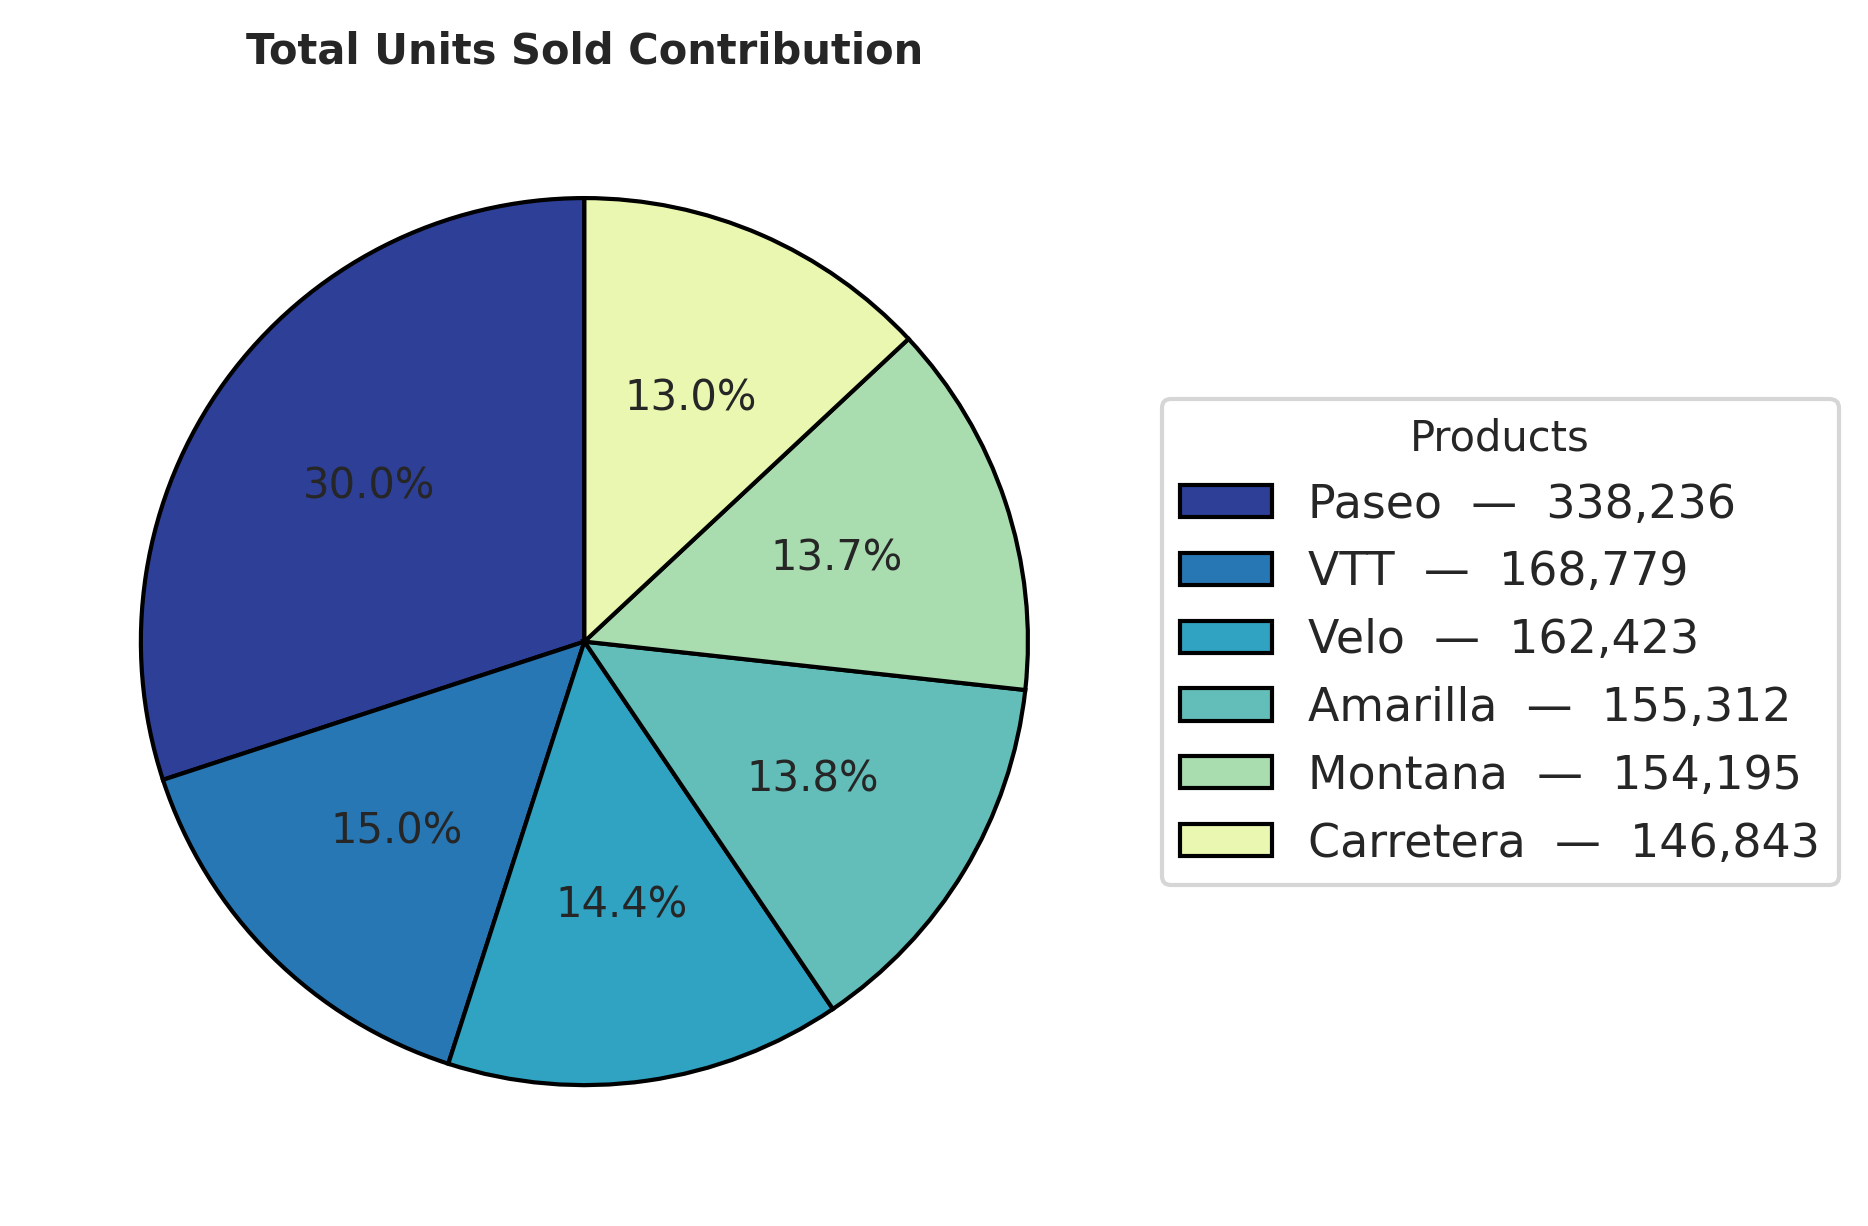

In [ ]:
product_units = df.groupby('Product')['Units Sold'].sum().sort_values(ascending=False)

colors = [
    '#2E3F98',  # dark blue
    '#2877B5',  # medium blue
    '#2FA3C1',  # teal blue
    '#63BDB9',  # light teal
    '#A9DDAF',  # light green
    '#EAF7B0'   # pale yellow-green
]

plt.figure(dpi = 150)
plt.pie(product_units, labels=None, autopct='%1.1f%%', startangle=90, colors=colors[:len(product_units)], textprops={'fontsize': 10}, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Total Units Sold Contribution', fontsize=10, fontweight='bold')

legend_labels = [
    f'{product}  —  {units:,.0f}'
    for product, units in product_units.items()
]

plt.legend(legend_labels, title='Products', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
plt.show()

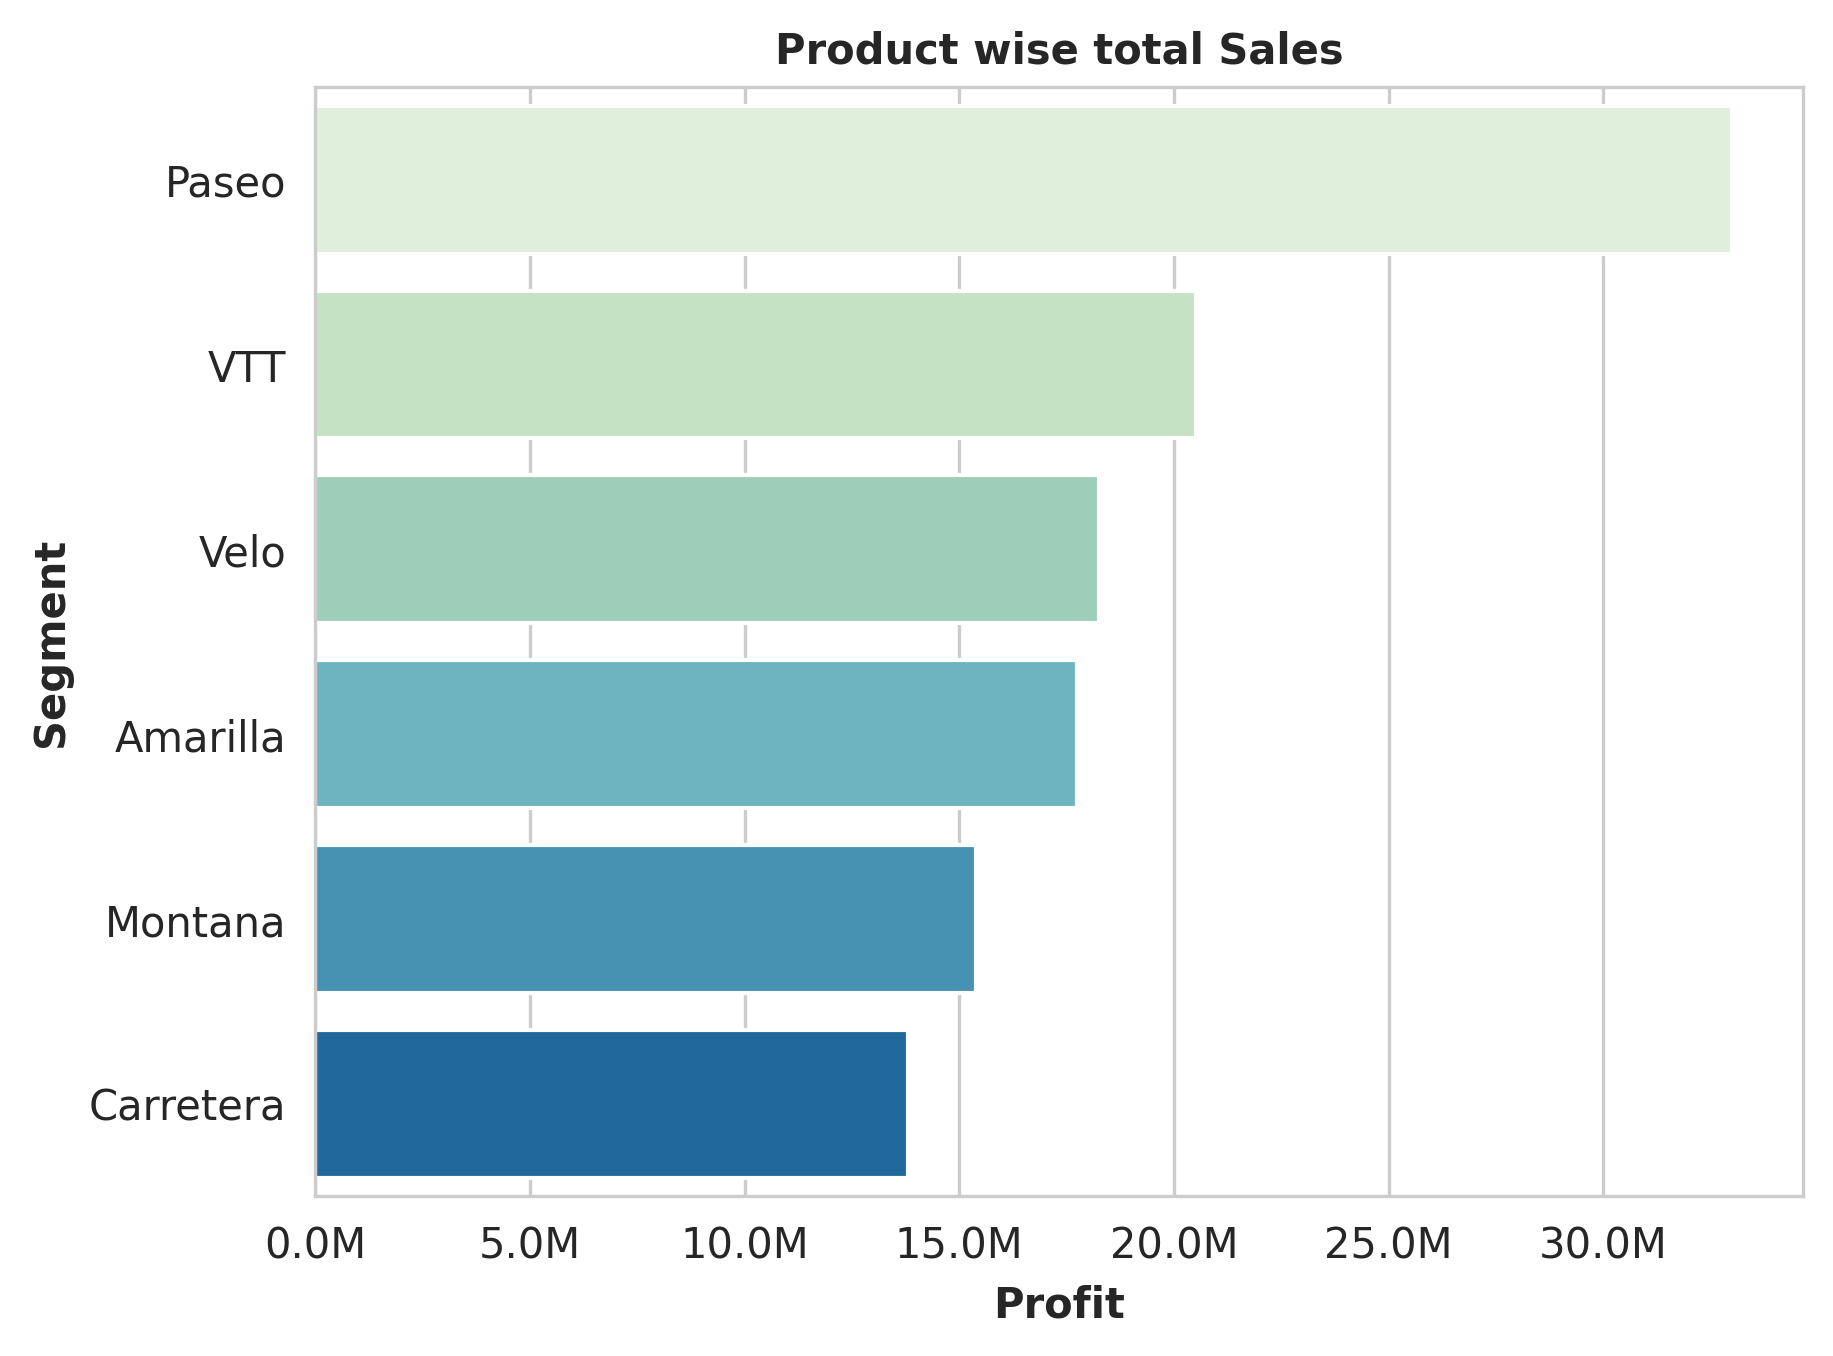

In [ ]:
colors = sns.color_palette("GnBu", len(top_products))
plt.figure(dpi = 150)
ax = sns.barplot(x = top_products['Sales'], y  = top_products['Product'], palette = colors)
format_axis_millions(ax, axis='x')
plt.xlabel("Profit", fontsize = 10, fontweight = 'bold')
plt.ylabel("Segment", fontsize = 10, fontweight = 'bold')
plt.title("Product wise total Sales", fontsize=10, fontweight="bold")
plt.show()

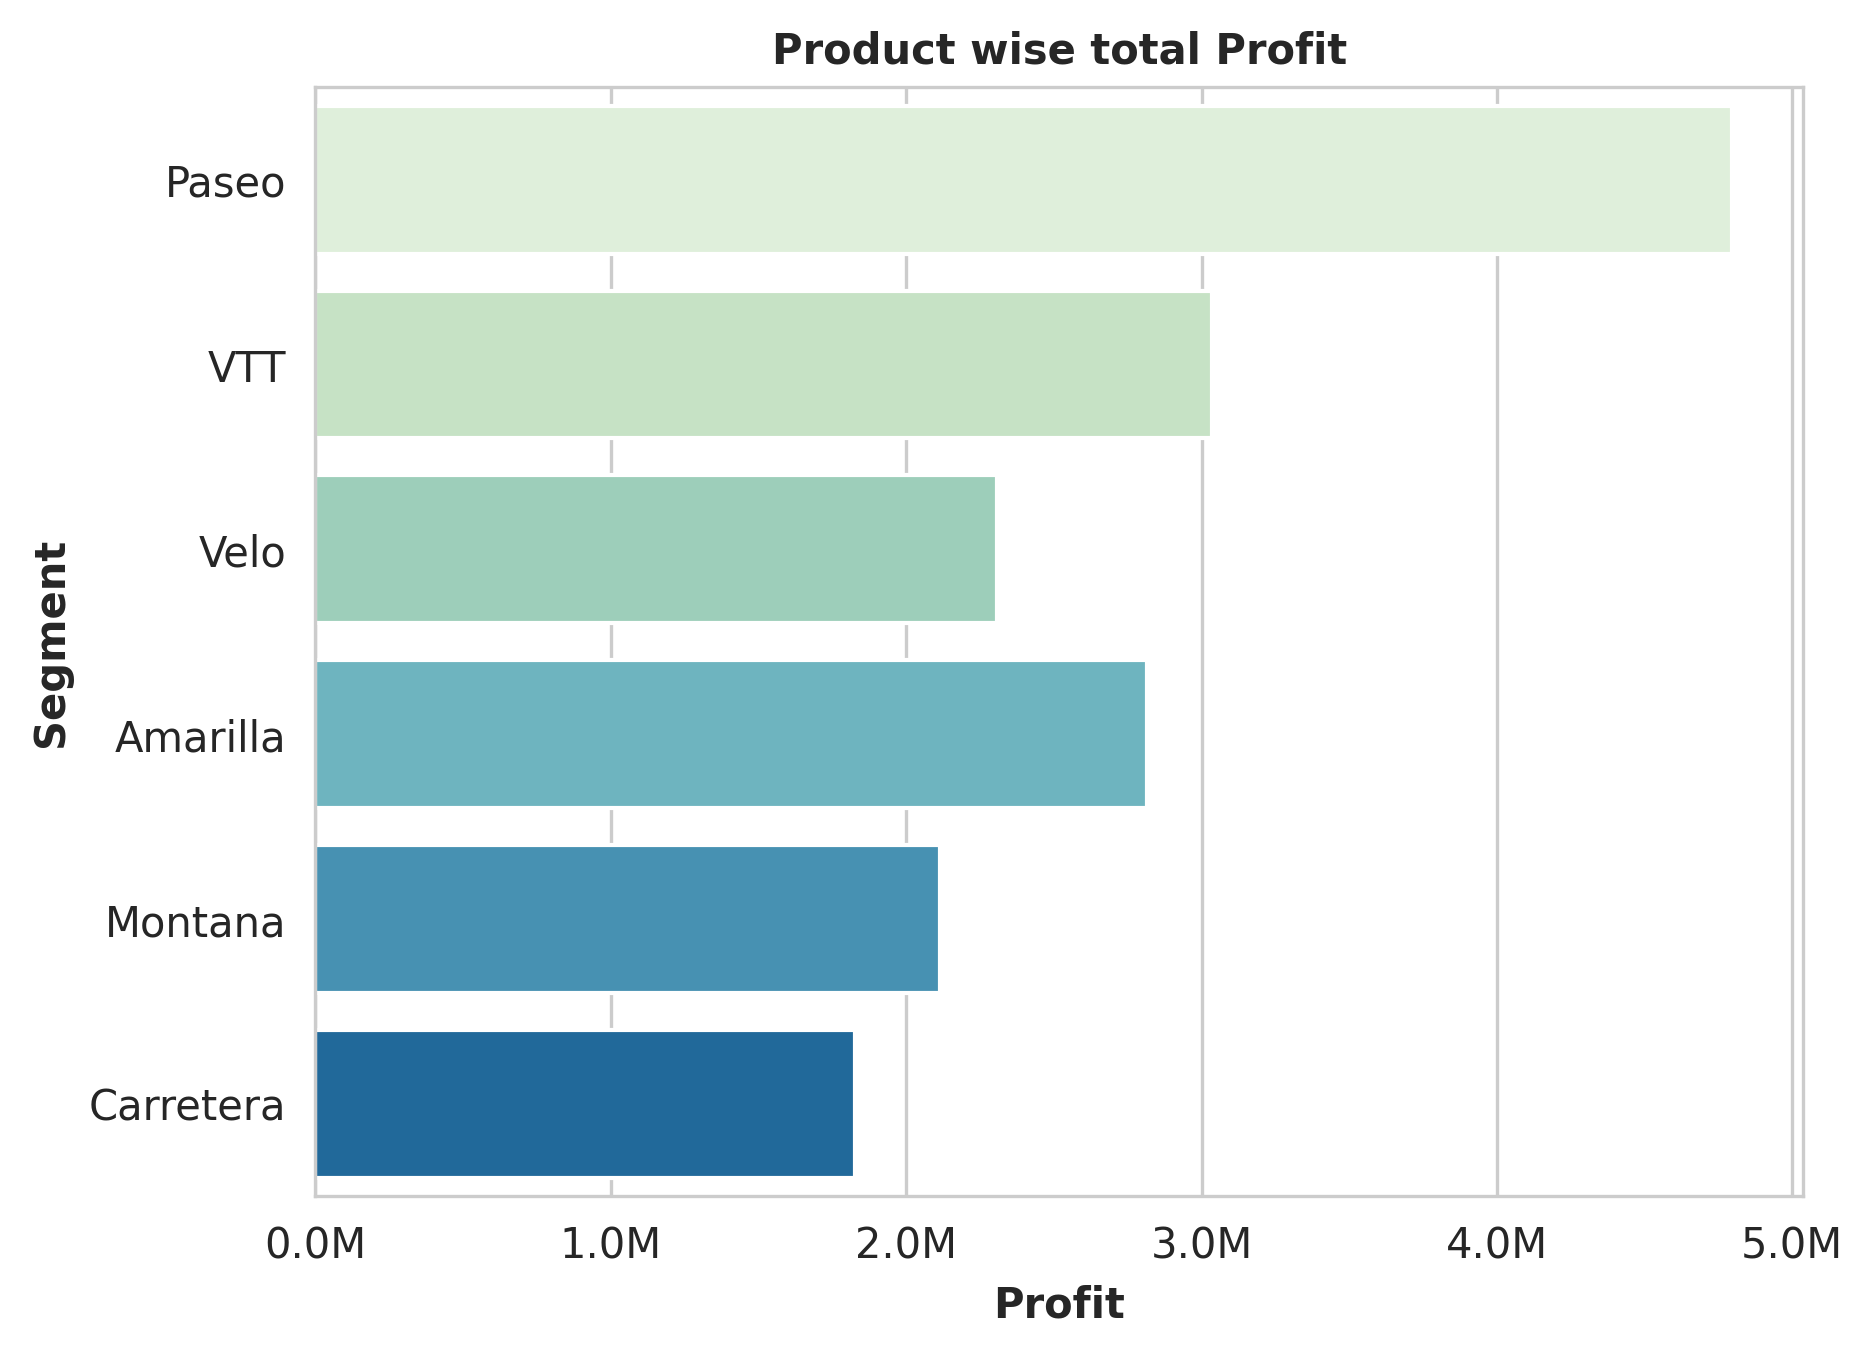

In [ ]:
colors = sns.color_palette("GnBu", len(top_products))
plt.figure(dpi = 150)
ax = sns.barplot(x = top_products['Profit'], y  = top_products['Product'], palette = colors)
format_axis_millions(ax, axis='x')
plt.xlabel("Profit", fontsize = 10, fontweight = 'bold')
plt.ylabel("Segment", fontsize = 10, fontweight = 'bold')
plt.title("Product wise total Profit", fontsize=10, fontweight="bold")
plt.show()

***4. Downloading the cleaned Excel file for PowerBI***

---



In [ ]:
df.to_excel("sales data cleaned.xlsx", index=False)